<a href="https://colab.research.google.com/github/Statofthe7/EncoderLLMMultilingualSentimentAnalysis/blob/main/AmazonLLMsmDeBERTaMultilingualSentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update # Up to date list of packages
# !apt-get install -y mecab libmecab-dev # Mecab and its libraries for Fugashi

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,927 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,827 kB]
Get:14 http://

In [ ]:
# Install dependencies
!pip install datasets pandas transformers torch sentencepiece openpyxl --quiet
# !pip install fugashi[unidic-lite]
!pip install anthropic openai google-generativeai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.2 MB/s eta 0:00:00


In [ ]:
# Imports
# from fugashi import Tagger
from transformers import AutoTokenizer, pipeline
import warnings
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm # for progress bar
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import confusion_matrix
from scipy import stats
import numpy as np
import anthropic
import openai
from google import genai
import time
from google.colab import userdata


In [ ]:
# This script loads Amazon Multilingual datasets (French and Japanese)
# Both datasets are Amazon product reviews
# Source: amazon_reviews_multi (Keung et al., 2020) via Hugging Face Datasets
# Load french and japanese parquet files to this project before running the script

# Load from local parquet files
fr_data = pd.read_parquet('/content/fr_test.parquet')
jp_data = pd.read_parquet('/content/ja_test.parquet')

# This part of the script calculates average and maximum "length" of reviews in both datasets
# For French, length is count of words in each review
# For Japanese, lenght is count of morphemes or sub-word tokens

# mDeBERTa-v3 is a multilingual version of DeBERTa (Decoding-enhanced BERT with distangled attention) and is a medium sized pre-trained model
# As part of fine-tuning on mnli and xnli datasets, it has learned to reason about a premise's entailment
# and contradiction to a hypothesis (NLI-Natural Language Inference) across different languages
tokenizer = AutoTokenizer.from_pretrained("MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")

# Setup Japanese Tagger to breakup text into space separated (owakati) morphemes
#tagger = Tagger('-Owakati')

# Get token length in Japanese
def get_japanese_token_length(text):

    # Using fugashi to parse text to morphemes separated by spaces and split to form a list
    # tokens = tagger.parse(text).split()

    # Using the model's native tokenizer (SentencePiece) to parse japanese text to sub-word tokens (similar to morphemes)
    tokens = tokenizer.encode(text)

    return len(tokens)

def get_stats(df, text_column, lang):
    df = pd.DataFrame(df)

    if lang == 'fr':
        # French: Use SentencePiece
        df['length'] = df[text_column].apply(lambda text: len(tokenizer.encode(text)))
    else:
        # Japanese: Split by morphemes using fugashi or sub-word tokens using SentencePiece
        df['length'] = df[text_column].apply(get_japanese_token_length)

    return df['length'].mean(), df['length'].max()

fr_mean, fr_max = get_stats(fr_data, 'text', 'fr')
jp_mean, jp_max = get_stats(jp_data, 'text', 'jp')

print(f"\n--- Statistical Results ---")
print(f"French   - Avg Tokens per Review: {fr_mean:.2f} (Max: {fr_max})")
print(f"Japanese - Avg Tokens per Review: {jp_mean:.2f} (Max: {jp_max})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

...

French DataFrame shape: (5000, 4)
Japanese DataFrame shape: (5000, 4)


,id,text,label,label_text
0,fr_0797681,ARNAQUE\n\nCa c'est du vol... Vous ne recevrez...,0,0
1,fr_0329266,NON REÇU!!!!\n\nPresque 1 mois après la comman...,0,0


,id,text,label,label_text
0,ja_0233954,剥がれて浮いてきた\n\n購入、貼付け後2週間もたたないうちに、上側から剥がれてきて画面から...,0,0
1,ja_0795959,所詮は中国製クオリティー・・・\n\n以下の3点の理由により、期待はずれの粗悪品。 ①他の方...,0,0


Token indices sequence length is longer than the specified maximum sequence length for this model (1191 > 512). Running this sequence through the model will result in indexing errors



--- Statistical Results ---
French   - Avg Tokens per Review: 56.57 (Max: 1191)
Japanese - Avg Tokens per Review: 56.16 (Max: 527)


In [ ]:
# This script creates a balanced sampling: 250 positive + 250 negative per language ─────────────

def process_sentiment(df, seed=42):
    mapping = {0: 'negative', 1: 'negative', 3: 'positive', 4: 'positive'}
    df_filtered = df[df['label'] != 2].copy()
    df_filtered['sentiment'] = df_filtered['label'].map(mapping)
    sampled = df_filtered.groupby('sentiment', group_keys=False).sample(n=250, random_state=seed)
    sampled = sampled.sample(frac=1, random_state=seed).reset_index(drop=True)
    return sampled

balanced_fr_data = process_sentiment(fr_data)
balanced_jp_data = process_sentiment(jp_data)

print(f'French sentiment counts:\n{balanced_fr_data["sentiment"].value_counts()}')
print(f'Japanese sentiment counts:\n{balanced_jp_data["sentiment"].value_counts()}')

French sentiment counts:
sentiment
positive    250
negative    250
Name: count, dtype: int64
Japanese sentiment counts:
sentiment
positive    250
negative    250
Name: count, dtype: int64


In [ ]:
# This script initialises mDeBERTa-v3 to perform zero-shot classification
# mDeBERTa-v3 is a multilingual DeBERTa model fine-tuned on MNLI and XNLI.
# Zero-Shot Pipeline is a NLP technique to perform classification
# on categories the pre-trained language model hasn't been trained on
# Here, it is implemented via NLI entailment scoring.

classifier = pipeline("zero-shot-classification",
                      model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
                      device=-1)  # Change to 0 if GPU is available

# Run Tests
# We use a 'hypothesis template' to guide the model's classification logic
# This works across french and japanese languages since the model is fine tuned to be cross-lingual

def test_sentiment(text, lang_name):
    result = classifier(text, ["positive", "negative"],
                        hypothesis_template="The sentiment is {}.")
    print(f"\n--- {lang_name} ---")
    print(f"Text: {text}")
    print(f"Top Label: {result['labels'][0]} ({result['scores'][0]:.2%})")

test_sentiment("Je me suis faite arnaqué Les pots sont pratiquement vide Le produits est de mauvaise qualité Je vous le déconseille", "French")
test_sentiment("5本中充電出来たのが2本だけでした。 レビューが高いのが不思議です。", "Japanese")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- French ---
Text: Je me suis faite arnaqué Les pots sont pratiquement vide Le produits est de mauvaise qualité Je vous le déconseille
Top Label: negative (99.88%)

--- Japanese ---
Text: 5本中充電出来たのが2本だけでした。 レビューが高いのが不思議です。
Top Label: positive (99.02%)


In [ ]:
# This script loads API keys from Colab Secrets and initializes the 3 LLMs
# Use the key icon in the left sidebar to enter yor keys

ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY    = userdata.get('OPENAI_API_KEY')
GEMINI_API_KEY    = userdata.get('GEMINI_API_KEY')

client_anthropic = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
client_openai    = openai.OpenAI(api_key=OPENAI_API_KEY)
client_gemini = genai.Client(api_key=GEMINI_API_KEY)

print("LLMs initialised.")

Clients initialised.


In [ ]:
# This script sets up the Prompt and classify functions for the 3 LLMs

PROMPT_TEMPLATE = (
    "Classify the sentiment of the following review as either 'positive' or 'negative'. "
    "Respond with a single word only.\n\nReview: {text}\n\nSentiment:"
)

def classify_claude(text):
    msg = client_anthropic.messages.create(
        model="claude-opus-4-6",
        max_tokens=5,
        messages=[{"role": "user", "content": PROMPT_TEMPLATE.format(text=text)}]
    )
    response = msg.content[0].text.strip().lower()
    return 'positive' if 'positive' in response else 'negative'

def classify_gemini(text):
    response = client_gemini.models.generate_content(
        model='gemini-3.1-pro-preview',
        contents=PROMPT_TEMPLATE.format(text=text))
    result   = response.text.strip().lower()
    return 'positive' if 'positive' in result else 'negative'

def classify_chatgpt(text):
    resp = client_openai.responses.create(
        model="gpt-5.4",
        input=PROMPT_TEMPLATE.format(text=text)
    )
    response = resp.output_text.strip().lower()
    return 'positive' if 'positive' in response else 'negative'

print("Classify functions ready.")

Classify functions ready.


In [ ]:
# This script runs sentiment analysis using a zero-shot classification with the encoder model mDeBERTa

def run_encoder(dataset, text_col, label_col, lang_name, num_samples=500):
    results = []
    print(f"\nRunning mDeBERTa on {lang_name}...")

    df_sample = pd.DataFrame(dataset).sample(num_samples, random_state=42)

    for _, row in tqdm(df_sample.iterrows(), total=num_samples):
        raw_text   = row[text_col]
        true_label = row[label_col]

        # Calculate Length based on language
        if lang_name == "Japanese":
           # processed_text = tagger.parse(raw_text) # Fugashi
            processed_text = raw_text
            token_length = len(tokenizer.encode(raw_text)) #SentencePiece
        else:
            processed_text = raw_text
            token_length = len(tokenizer.encode(raw_text)) #SentencePiece

        # Run AI prediction
        output = classifier(processed_text, ["positive", "negative"],
                                hypothesis_template="The sentiment is {}.")
        pred_label = output['labels'][0]
        confidence = output['scores'][0]

        results.append({
            "raw_text"           : raw_text,
            "processed_text"     : processed_text,
            "token_length"       : token_length,
            "true_label"         : true_label,
            "mDeBERTa_pred"      : pred_label,
            "mDeBERTa_correct"   : true_label == pred_label,
            "mDeBERTa_confidence": confidence,
        })

    return pd.DataFrame(results)

df_fr = run_encoder(balanced_fr_data, 'text', 'sentiment', "French")
df_jp = run_encoder(balanced_jp_data, 'text', 'sentiment', "Japanese")

print(f"\nmDeBERTa Accuracy French:   {df_fr['mDeBERTa_correct'].mean():.1%}")
print(f"mDeBERTa Accuracy Japanese: {df_jp['mDeBERTa_correct'].mean():.1%}")


Running mDeBERTa on French...


100%|██████████| 500/500 [1:09:14<00:00,  8.31s/it]



Running mDeBERTa on Japanese...


 70%|███████   | 350/500 [49:13<17:22,  6.95s/it]

In [ ]:
# This script runs sentiment analysis using Claude

def run_claude(df, lang_name):
    print(f"\nRunning Claude on {lang_name}...")
    preds = []

    for t in tqdm(df['text'], total=len(df)):
        preds.append(classify_claude(t))

    df['Claude_pred']    = preds
    df['Claude_correct'] = df['Claude_pred'] == df['true_label']
    print(f"Claude {lang_name} accuracy: {df['Claude_correct'].mean():.1%}")
    return df

df_fr = run_claude(df_fr, "French")
df_jp = run_claude(df_jp, "Japanese")


In [ ]:
# This script runs sentiment analysis using ChatGPT

def run_chatgpt(df, lang_name):
    print(f"\nRunning ChatGPT on {lang_name}...")
    preds = []

    for t in tqdm(df['text'], total=len(df)):
        preds.append(classify_chatgpt(t))

    df['ChatGPT_pred']    = preds
    df['ChatGPT_correct'] = df['ChatGPT_pred'] == df['true_label']
    print(f"ChatGPT {lang_name} accuracy: {df['ChatGPT_correct'].mean():.1%}")
    return df

df_fr = run_chatgpt(df_fr, "French")
df_jp = run_chatgpt(df_jp, "Japanese")


In [ ]:
# This script runs sentiment analysis using Gemini
# It saves all model results into two csv files

def run_gemini(df, lang_name):
    print(f"\nRunning Gemini on {lang_name}...")
    preds = []

    for t in tqdm(df['raw_text'], total=len(df)):
        preds.append(classify_gemini(t))

    df['Gemini_pred']    = preds
    df['Gemini_correct'] = df['Gemini_pred'] == df['true_label']
    print(f"Gemini {lang_name} accuracy: {df['Gemini_correct'].mean():.1%}")
    return df

df_fr = run_gemini(df_fr, "French")
df_jp = run_gemini(df_jp, "Japanese")

# Final save with all model results
df_fr.to_csv("french_results.csv", index=False)
df_jp.to_csv("japanese_results.csv", index=False)

print("All results saved to french_results.csv and japanese_results.csv")

# Full accuracy summary
print("\n Accuracy Summary")
for lang, df in [("French", df_fr), ("Japanese", df_jp)]:
    print(f"\n{lang}:")
    print(f"  mDeBERTa : {df['mDeBERTa_correct'].mean():.1%}")
    print(f"  Claude   : {df['Claude_correct'].mean():.1%}")
    print(f"  ChatGPT  : {df['ChatGPT_correct'].mean():.1%}")
    print(f"  Gemini   : {df['Gemini_correct'].mean():.1%}")


In [1]:
# Beginning of scripts to analyze model results
# Load results from saved CSVs, if analyzing from CSVs

df_fr = pd.read_csv("french_results.csv")
df_jp = pd.read_csv("japanese_results.csv")


French  N=500, label balance: {'positive': 250, 'negative': 250}
Japanese N=500, label balance: {'positive': 250, 'negative': 250}


,raw_text,token_length,true_label,mDeBERTa_pred,mDeBERTa_correct,mDeBERTa_confidence,Claude_pred,Claude_correct,ChatGPT_pred,ChatGPT_correct,Gemini_pred,Gemini_correct
0,"ok\n\nFait le boulot que j'ai besoin, je n'ai ...",65,positive,negative,False,0.915034,positive,True,positive,True,positive,True
1,Ruban adhésif licorne\n\nMa nièce adore ce rub...,83,positive,positive,True,0.984767,positive,True,positive,True,positive,True
2,Que de souvenirs...\n\nPas exactement les même...,86,positive,positive,True,0.997897,positive,True,positive,True,positive,True


In [2]:
# TABLE 1: Overall accuracy and cross-lingual gap
# Chi-square tests use Yates' continuity correction.

model_cols = {
    'mDeBERTa': 'mDeBERTa_correct',
    'Claude'  : 'Claude_correct',
    'Gemini'  : 'Gemini_correct',
    'ChatGPT' : 'ChatGPT_correct',
}

rows = []
for model_name, col in model_cols.items():
    jp_c = df_jp[col].sum();  jp_n = len(df_jp)
    fr_c = df_fr[col].sum();  fr_n = len(df_fr)
    jp_acc = jp_c / jp_n
    fr_acc = fr_c / fr_n
    gap    = jp_acc - fr_acc
    contingency = [[jp_c, jp_n - jp_c], [fr_c, fr_n - fr_c]]
    chi2, p, _, _ = stats.chi2_contingency(contingency, correction=True)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    rows.append({
        'Model'            : model_name,
        'Japanese Accuracy': f'{jp_acc:.1%}',
        'French Accuracy'  : f'{fr_acc:.1%}',
        'Gap'              : f'{gap:.1%}',
        'χ²'               : f'{chi2:.2f}',
        'p-value'          : f'{p:.3f}{sig}',
    })

table1 = pd.DataFrame(rows)
print("Table 1. Overall accuracy and cross-lingual gap by model.")
print("Note: χ² tests use Yates' continuity correction. *p<0.05, **p<0.01, ***p<0.001\n")
print(table1.to_string(index=False))

Table 1. Overall accuracy and cross-lingual gap by model.
Note: χ² tests use Yates' continuity correction. *p<0.05, **p<0.01, ***p<0.001

   Model Japanese Accuracy French Accuracy   Gap   χ² p-value
mDeBERTa             88.4%           92.2% -3.8% 3.70   0.054
  Claude             96.0%           96.4% -0.4% 0.03   0.869
  Gemini             96.2%           96.8% -0.6% 0.12   0.731
 ChatGPT             96.0%           95.4%  0.6% 0.10   0.755


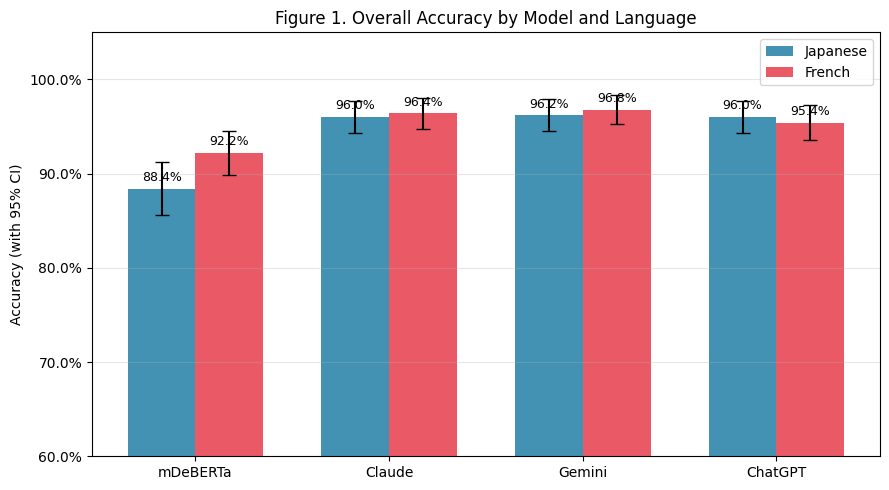

Saved: figure1_accuracy_with_ci.png


In [3]:
# FIGURE 1: Accuracy by model and language with 95% CI

def compute_ci(p, n):
    se = np.sqrt(p * (1 - p) / n)
    return 1.96 * se

fig, ax = plt.subplots(figsize=(9, 5))
models = list(model_cols.keys())
x      = np.arange(len(models))
width  = 0.35
n      = len(df_jp)

jp_accs = [df_jp[col].mean() for col in model_cols.values()]
fr_accs = [df_fr[col].mean() for col in model_cols.values()]
jp_cis  = [compute_ci(p, n) for p in jp_accs]
fr_cis  = [compute_ci(p, n) for p in fr_accs]

bars_jp = ax.bar(x - width/2, jp_accs, width, yerr=jp_cis, capsize=5,
                 label='Japanese', color='#2E86AB', alpha=0.9)
bars_fr = ax.bar(x + width/2, fr_accs, width, yerr=fr_cis, capsize=5,
                 label='French',   color='#E84855', alpha=0.9)

for bar in bars_jp + bars_fr:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.1%}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (with 95% CI)')
ax.set_ylim(0.6, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Figure 1. Overall Accuracy by Model and Language')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_accuracy_with_ci.png', dpi=300)
plt.show()
print("Saved: figure1_accuracy_with_ci.png")

In [4]:
# TABLE 2: Point-biserial correlations (document length vs. accuracy)

rows2 = []
for model_name, col in model_cols.items():
    for lang, df in [('Japanese', df_jp), ('French', df_fr)]:
        lengths = df['token_length'].values
        correct = df[col].astype(int).values
        r, p    = stats.pointbiserialr(lengths, correct)
        sig     = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        rows2.append({
            'Model': model_name, 'Language': lang,
            'r': f'{r:+.3f}', 'p': f'{p:.3f}{sig}',
        })

table2      = pd.DataFrame(rows2)
table2_wide = table2.pivot(index='Model', columns='Language', values=['r', 'p'])
table2_wide.columns = ['French r', 'Japanese r', 'French p', 'Japanese p']
table2_wide = table2_wide[['Japanese r', 'Japanese p', 'French r', 'French p']]
table2_wide = table2_wide.loc[list(model_cols.keys())]
print("Table 2. Point-biserial correlation between token length and accuracy.")
print("Note: *p<0.05, **p<0.01, ***p<0.001\n")
print(table2_wide.to_string())

Table 2. Point-biserial correlation between token length and accuracy.
Note: *p<0.05, **p<0.01, ***p<0.001

         Japanese r Japanese p French r French p
Model                                           
mDeBERTa     -0.013      0.773   +0.010    0.819
Claude       -0.106     0.018*   +0.006    0.898
Gemini       -0.070      0.119   +0.017    0.698
ChatGPT      -0.002      0.968   +0.050    0.265


In [6]:
# TABLE 3: Accuracy by token-length bin
# Bin convention: exclusive lower bound, inclusive upper (lo, hi]

bin_edges  = [0, 20, 40, 60, 100, 200, float('inf')]
bin_labels = ['0-20', '20-40', '40-60', '60-100', '100-200', '200+']

for df in [df_fr, df_jp]:
    df['length_bin'] = pd.cut(df['token_length'], bins=bin_edges,
                              labels=bin_labels, right=True)

rows3 = []
for label in bin_labels:
    row = {'Token Bin': label}
    for model_name, col in [('mDeBERTa', 'mDeBERTa_correct'), ('ChatGPT', 'ChatGPT_correct'), ('Gemini', 'Gemini_correct'), ('Claude', 'Claude_correct')]:
        for lang, df in [('JP', df_jp), ('FR', df_fr)]:
            sub = df[df['length_bin'] == label]
            acc = sub[col].mean() if len(sub) > 0 else float('nan')
            n   = len(sub)
            row[f'{model_name} {lang}'] = f'{acc:.1%} (n={n})'
    rows3.append(row)

table3 = pd.DataFrame(rows3)
print("Table 3. Accuracy by token-length bin for mDeBERTa-v3, ChatGPT, Claude and Gemini.")
print()
print(table3.to_string(index=False))

Table 3. Accuracy by token-length bin for mDeBERTa-v3, ChatGPT, Claude and Gemini.

Token Bin   mDeBERTa JP   mDeBERTa FR    ChatGPT JP    ChatGPT FR     Gemini JP     Gemini FR     Claude JP     Claude FR
     0-20  94.1% (n=34)  95.2% (n=62) 100.0% (n=34)  93.5% (n=62)  97.1% (n=34)  98.4% (n=62) 100.0% (n=34)  98.4% (n=62)
    20-40 87.9% (n=206) 92.6% (n=148) 95.1% (n=206) 94.6% (n=148) 95.6% (n=206) 95.9% (n=148) 95.6% (n=206) 95.9% (n=148)
    40-60 91.7% (n=109) 89.7% (n=126) 99.1% (n=109) 96.0% (n=126) 99.1% (n=109) 96.0% (n=126) 98.2% (n=109) 96.0% (n=126)
   60-100  86.0% (n=93) 92.5% (n=106)  93.5% (n=93) 95.3% (n=106)  94.6% (n=93) 97.2% (n=106)  94.6% (n=93) 95.3% (n=106)
  100-200  85.7% (n=49)  92.5% (n=53)  93.9% (n=49)  98.1% (n=53)  95.9% (n=49)  98.1% (n=53)  95.9% (n=49)  98.1% (n=53)
     200+   77.8% (n=9)  100.0% (n=5)  100.0% (n=9)  100.0% (n=5)   88.9% (n=9)  100.0% (n=5)   77.8% (n=9)  100.0% (n=5)


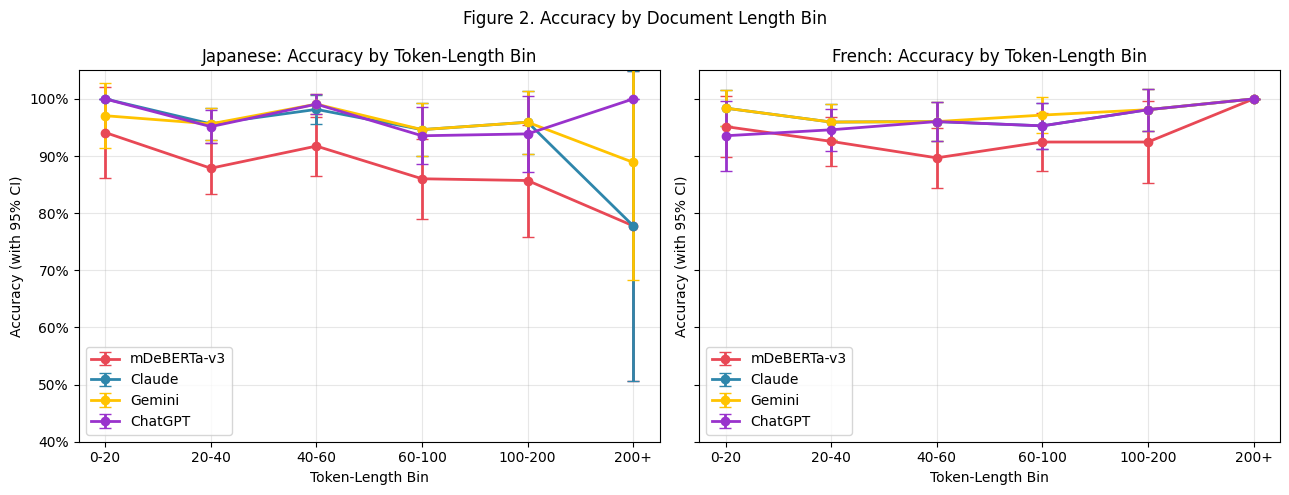

Saved: figure2_length_bins_with_ci.png


In [8]:
# FIGURE 2: Length-bin accuracy with 95% CI

def compute_bin_stats(df, col):
    means, cis = [], []
    for b in bin_labels:
        bin_df = df[df['length_bin'] == b]
        n = len(bin_df)
        if n == 0:
            means.append(np.nan); cis.append(np.nan); continue
        p  = bin_df[col].mean()
        se = np.sqrt(p * (1 - p) / n)
        means.append(p); cis.append(1.96 * se)
    return means, cis

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
colors     = {'mDeBERTa_correct': '#E84855', 'Claude_correct': '#2E86AB',
              'Gemini_correct': '#FFC300', 'ChatGPT_correct': '#9932CC'}
labels_map = {'mDeBERTa_correct': 'mDeBERTa-v3', 'Claude_correct': 'Claude',
              'Gemini_correct': 'Gemini', 'ChatGPT_correct': 'ChatGPT'}

for ax, (lang_name, df) in zip(axes, [('Japanese', df_jp), ('French', df_fr)]):
    for col, color in colors.items():
        means, cis = compute_bin_stats(df, col)
        ax.errorbar(bin_labels, means, yerr=cis,
                    marker='o', linewidth=2, capsize=4,
                    label=labels_map[col], color=color)
    ax.set_title(f'{lang_name}: Accuracy by Token-Length Bin')
    ax.set_xlabel('Token-Length Bin')
    ax.set_ylabel('Accuracy (with 95% CI)')
    ax.set_ylim(0.4, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Figure 2. Accuracy by Document Length Bin')
plt.tight_layout()
plt.savefig('figure2_length_bins_with_ci.png', dpi=300)
plt.show()
print("Saved: figure2_length_bins_with_ci.png")

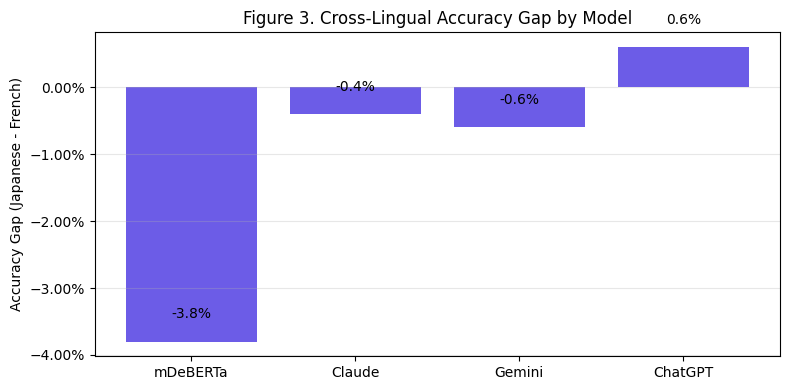

Saved: figure3_gap.png


In [9]:
# FIGURE 3: Cross-Lingual Gap by Model

gaps = [jp - fr for jp, fr in zip(jp_accs, fr_accs)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, gaps, color='#6C5CE7')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.1%}',
            ha='center', va='bottom')

ax.set_ylabel('Accuracy Gap (Japanese - French)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Figure 3. Cross-Lingual Accuracy Gap by Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure3_gap.png', dpi=300)
plt.show()
print("Saved: figure3_gap.png")

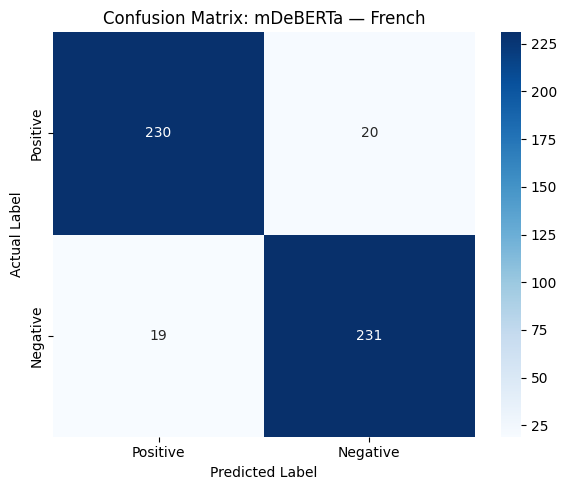

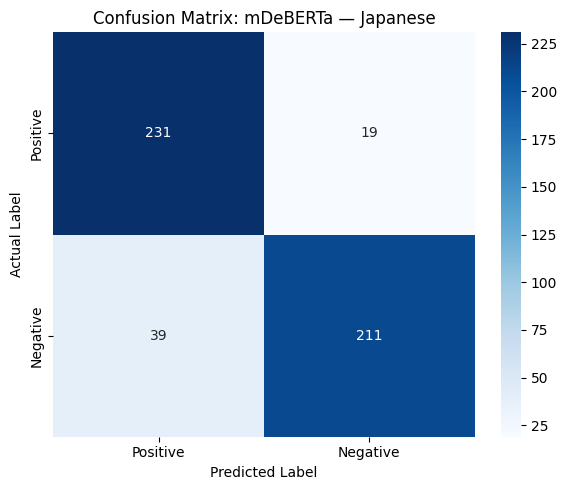

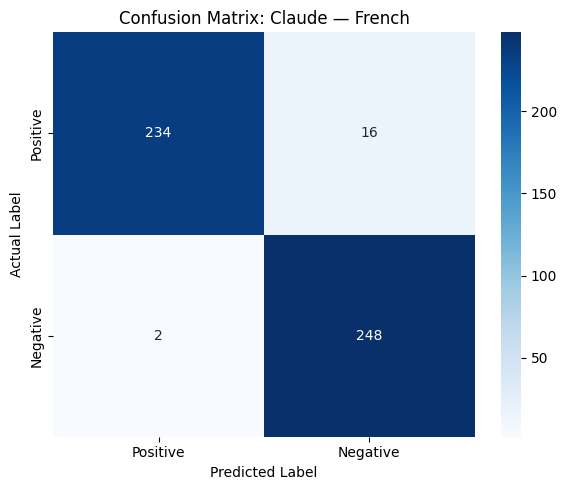

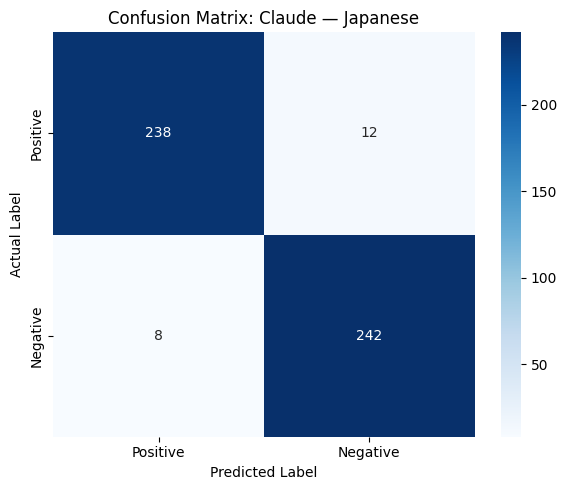

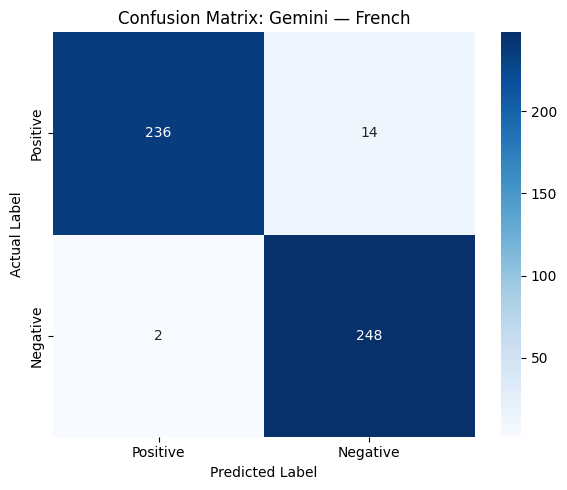

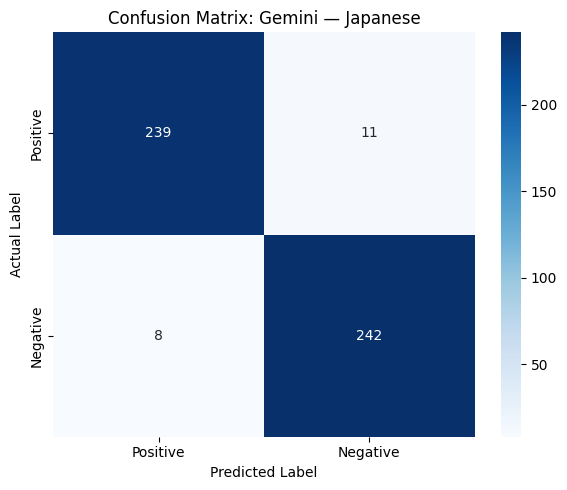

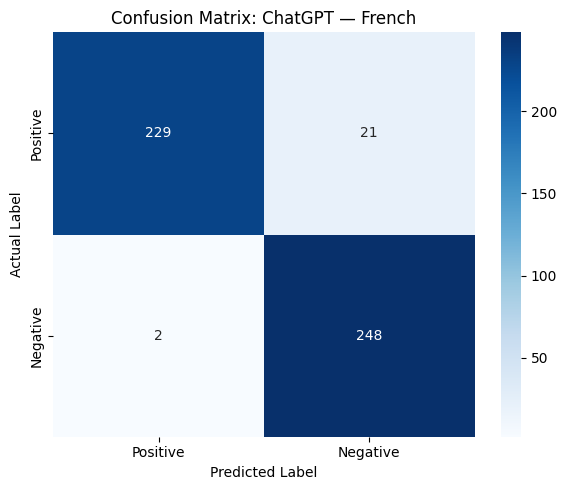

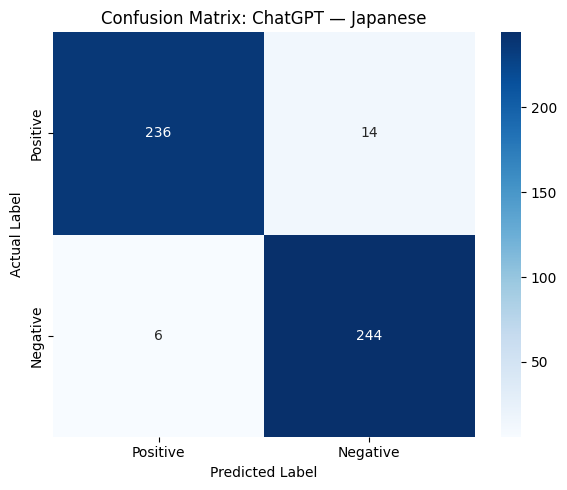

In [11]:
# This script charts confusion matrices for all models and for both French and Japanese sentiment analysis

model_pred_cols = {
    'mDeBERTa': 'mDeBERTa_pred',
    'Claude'  : 'Claude_pred',
    'Gemini'  : 'Gemini_pred',
    'ChatGPT' : 'ChatGPT_pred',
}

def plot_confusion_matrix(df, model_col, model_name, lang_name):
    cm = confusion_matrix(df['true_label'], df[model_col],
                          labels=["positive", "negative"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Positive", "Negative"],
                yticklabels=["Positive", "Negative"])
    plt.title(f'Confusion Matrix: {model_name} — {lang_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

for model_name, col in model_pred_cols.items():
    plot_confusion_matrix(df_fr, col, model_name, "French")
    plot_confusion_matrix(df_jp, col, model_name, "Japanese")

In [12]:
# STATISTICAL SUMMARY: accuracy + length correlation for all models and save as a CSV

def generate_statistical_summary(df_fr, df_jp):
    summary_data = []
    for model_name, col in model_cols.items():
        for df, lang in [(df_fr, "French"), (df_jp, "Japanese")]:
            mean_acc      = df[col].mean()
            r_val, p_val  = stats.pointbiserialr(df['token_length'], df[col].astype(int))
            summary_data.append({
                "Model"          : model_name,
                "Language"       : lang,
                "Mean Accuracy"  : f"{mean_acc:.2%}",
                "Correlation (r)": f"{r_val:.3f}",
                "P-Value"        : f"{p_val:.4f}",
                "Significance"   : "Significant" if p_val < 0.05 else "Not Significant"
            })
    return pd.DataFrame(summary_data)

results_table = generate_statistical_summary(df_fr, df_jp)
print(results_table.to_string(index=False))
results_table.to_csv("statistical_summary.csv", index=False)
print("\nSaved: statistical_summary.csv")

   Model Language Mean Accuracy Correlation (r) P-Value    Significance
mDeBERTa   French        92.20%           0.010  0.8186 Not Significant
mDeBERTa Japanese        88.40%          -0.013  0.7733 Not Significant
  Claude   French        96.40%           0.006  0.8984 Not Significant
  Claude Japanese        96.00%          -0.106  0.0182     Significant
  Gemini   French        96.80%           0.017  0.6977 Not Significant
  Gemini Japanese        96.20%          -0.070  0.1188 Not Significant
 ChatGPT   French        95.40%           0.050  0.2649 Not Significant
 ChatGPT Japanese        96.00%          -0.002  0.9676 Not Significant

Saved: statistical_summary.csv


In [13]:
# SUPPLEMENTARY: label composition of long French reviews
# Checks whether the 200+ token bin has a skewed label distribution

long_fr      = df_fr[df_fr['length_bin'] == '200+']
label_counts = long_fr['true_label'].value_counts()
pct_pos      = label_counts.get('positive', 0) / len(long_fr)

print(f"French 200+ token bin: n={len(long_fr)}, "
      f"positive={label_counts.get('positive', 0)} ({pct_pos:.0%}), "
      f"negative={label_counts.get('negative', 0)}")

# mDeBERTa error breakdown in longest bin
errors = long_fr[long_fr['mDeBERTa_correct'] == False]
print(f"\nmDeBERTa errors in 200+ bin: {len(errors)} total")
print(f"  Positive reviews misclassified: {(errors['true_label'] == 'positive').sum()}")
print(f"  Negative reviews misclassified: {(errors['true_label'] == 'negative').sum()}")

French 200+ token bin: n=5, positive=3 (60%), negative=2

mDeBERTa errors in 200+ bin: 0 total
  Positive reviews misclassified: 0
  Negative reviews misclassified: 0


In [14]:
# SUPPLEMENTARY: label composition of long Japanese reviews
# Checks whether the 200+ token bin has a skewed label distribution

long_jp      = df_jp[df_jp['length_bin'] == '200+']
label_counts = long_jp['true_label'].value_counts()
pct_pos      = label_counts.get('positive', 0) / len(long_jp)

print(f"Japanese 200+ token bin: n={len(long_jp)}, "
      f"positive={label_counts.get('positive', 0)} ({pct_pos:.0%}), "
      f"negative={label_counts.get('negative', 0)}")

# mDeBERTa error breakdown in longest bin
errors = long_jp[long_jp['mDeBERTa_correct'] == False]
print(f"\nmDeBERTa errors in 200+ bin: {len(errors)} total")
print(f"  Positive reviews misclassified: {(errors['true_label'] == 'positive').sum()}")
print(f"  Negative reviews misclassified: {(errors['true_label'] == 'negative').sum()}")

Japanese 200+ token bin: n=9, positive=2 (22%), negative=7

mDeBERTa errors in 200+ bin: 2 total
  Positive reviews misclassified: 0
  Negative reviews misclassified: 2
